\# MATH 4340 / COSC 4340: Numerical Methods for Differential Equations
# Notebook 10: Gaussian Elimination

### Professor: Dane Taylor
### Date: Spring 2024


In [1]:
%pylab inline
import timeit

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## 1. Gaussian Elimination and LU decomposition

In [10]:
def GE_solver(A0,b0):
    A = array(A0)
    L = np.eye(len(A))
    b = array(b0)
    n = A.shape[0]
    for k in range(n-1): #column k        
        for i in range(k+1,n):#row i
            m = A[i,k]/ A[k,k]
            L[i,k] = m
#            A[i,k:] -= m*A[k,k:]
            for j in range(k,n):
                A[i,j] -= m*A[k,j]
            b[i] = b[i] - m*b[k]    
    U = np.array(A) # lower triangular matrix

    #backsolve for x
    g = np.array(b)
    x = np.zeros(n)
    x[n-1] = g[n-1]/U[n-1,n-1]
    for k in reversed(list(arange(n-1))):
        x[k] = (g[k] - sum(U[k,(k+1):]*x[(k+1):]) ) / U[k,k]
    return x,L,U,g

In [11]:
A = array([[1,2,1],
           [2,2,3],
           [-1,-3,0]],dtype=float)
b=array([0,3,2],dtype=float)
x,L,U,g = GE_solver(A,b)
print(U,'\n\n',L)
print('\n',L@U)

[[ 1.   2.   1. ]
 [ 0.  -2.   1. ]
 [ 0.   0.   0.5]] 

 [[ 1.   0.   0. ]
 [ 2.   1.   0. ]
 [-1.   0.5  1. ]]

 [[ 1.  2.  1.]
 [ 2.  2.  3.]
 [-1. -3.  0.]]


In [12]:
print(g,'\n\n',x)
print('\n',L@g)
print('\n',A@x)

[0.  3.  0.5] 

 [ 1. -1.  1.]

 [0. 3. 2.]

 [0. 3. 2.]


## 2. Computational Complexity for GE method

In [13]:
N = 500
A = random.rand(N,N)
b = random.rand(N)

x,L,U,g = GE_solver(A,b)
TRIALS=10
runtime = timeit.timeit('GE_solver(A,b)', globals=globals(),  number=TRIALS)/TRIALS
runtime

7.013938266737386

In [14]:
Ns = array(logspace(2,3,4),dtype=int)
Ns

array([ 100,  215,  464, 1000])

In [15]:
runtimes = zeros(len(Ns))
for i,N in enumerate(Ns):
    A = random.rand(N,N)
    b = random.rand(N)

    #x,L,U,g = GE_solver(A,b)
    TRIALS=1
    runtimes[i] = timeit.timeit('GE_solver(A,b)', globals=globals(),  number=TRIALS)/TRIALS

Text(0, 0.5, 'runtime in seconds')

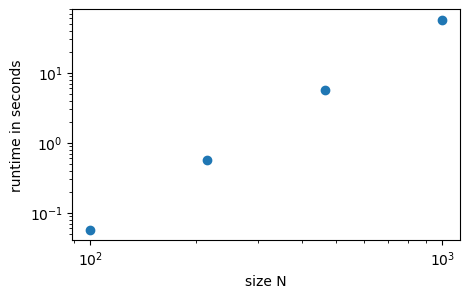

In [16]:
fig2, ax = subplots(1,1, figsize=(5,3))
loglog(Ns,runtimes,'o ')
xlabel('size N')
ylabel('runtime in seconds')

In [17]:
np.polyfit(log(Ns), log(runtimes), 1)

array([  2.99907387, -16.66798346])

## 3. Condition Numbers

In [31]:
N = 10
A = random.rand(N,N)
cond(A,'fro')

47.68660636769405

In [32]:
Ns = array(logspace(1,3,5),dtype=int)
Ns

array([  10,   31,  100,  316, 1000])

In [33]:
condition_numbers = zeros(len(Ns))
for i,N in enumerate(Ns):
    A = random.rand(N,N)
    condition_numbers[i] = cond(A,'fro')

Text(0, 0.5, 'condition numbers')

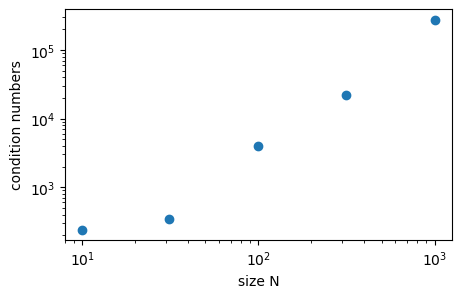

In [34]:
fig2, ax = subplots(1,1, figsize=(5,3))
loglog(Ns,condition_numbers,'o ')
xlabel('size N')
ylabel('condition numbers')

In [ ]:
np.polyfit(log(Ns), log(condition_numbers), 1)